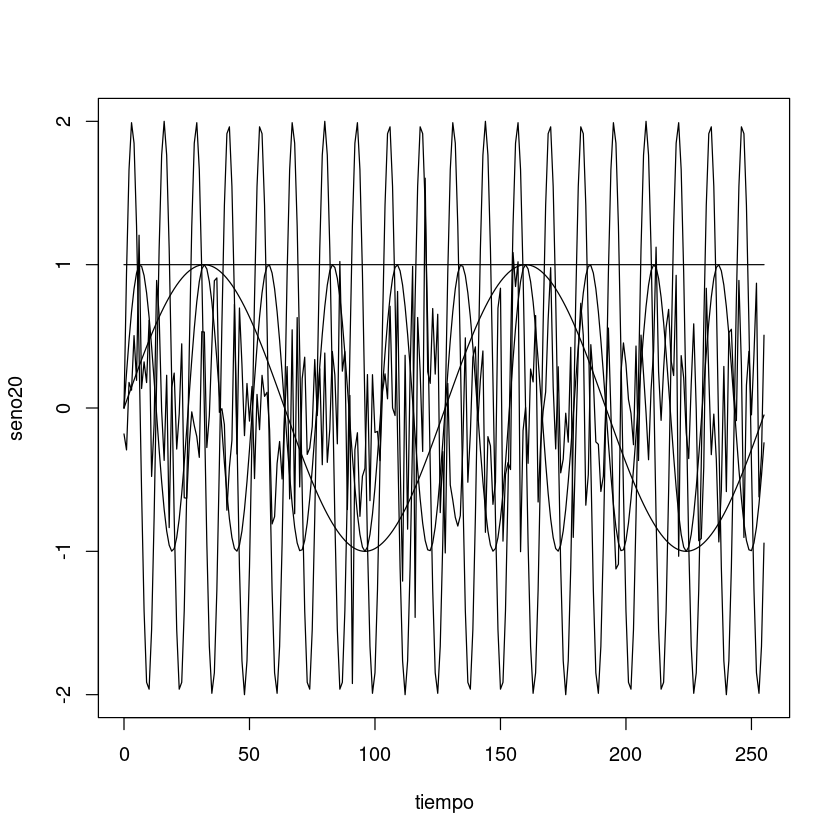

In [15]:
N = 256
tiempo = 0:(N-1)

ciclos = 2
amplitud = 1
seno2 = amplitud*sin(ciclos*2*pi*tiempo/N)

ciclos = 10
amplitud = 1
seno10 = amplitud*sin(ciclos*2*pi*tiempo/N)

ciclos = 20
amplitud = 2
seno20 = amplitud*sin(ciclos*2*pi*tiempo/N)

niveldc = rep(1,N)
nivelruido = rnorm(N, mean=0, sd=0.5)

plot(tiempo, seno20, type='l')
lines(tiempo,seno2)
lines(tiempo,seno10)
lines(tiempo, niveldc)
lines(tiempo, nivelruido)

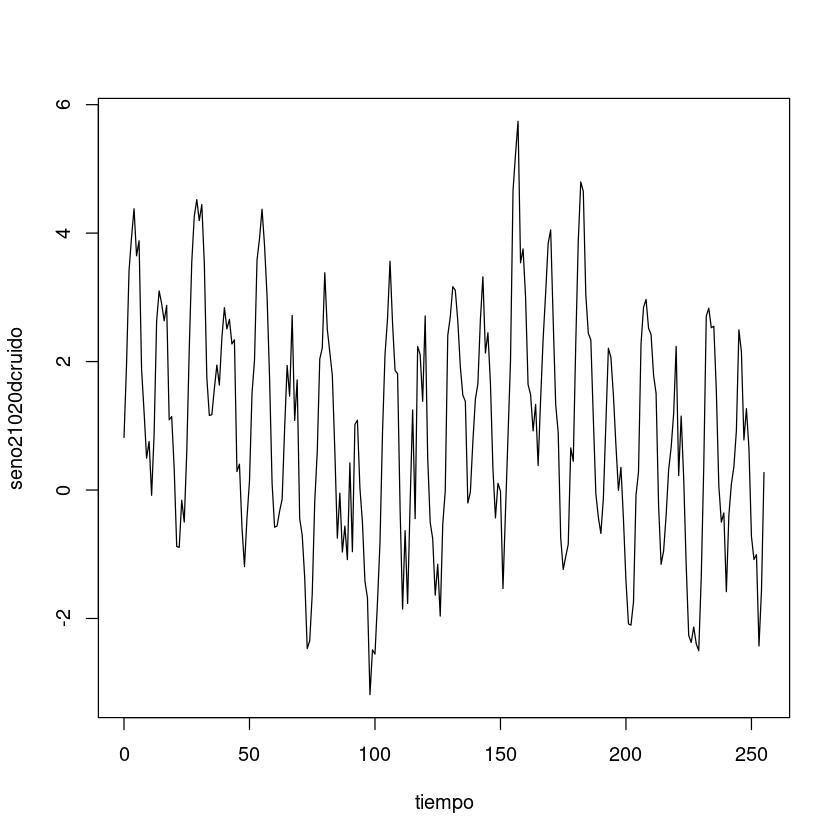

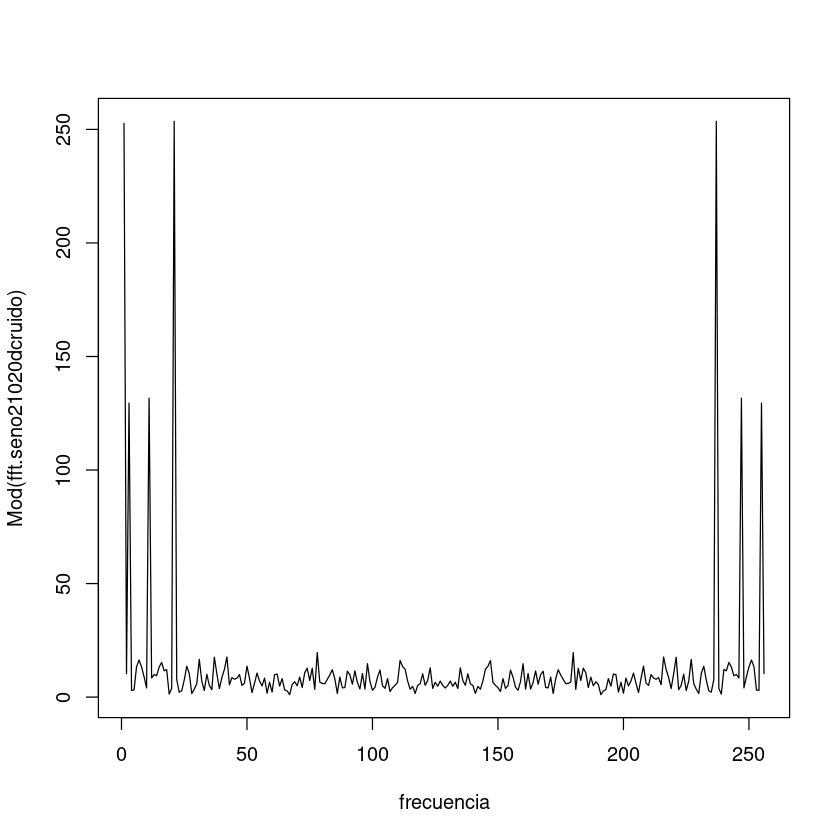

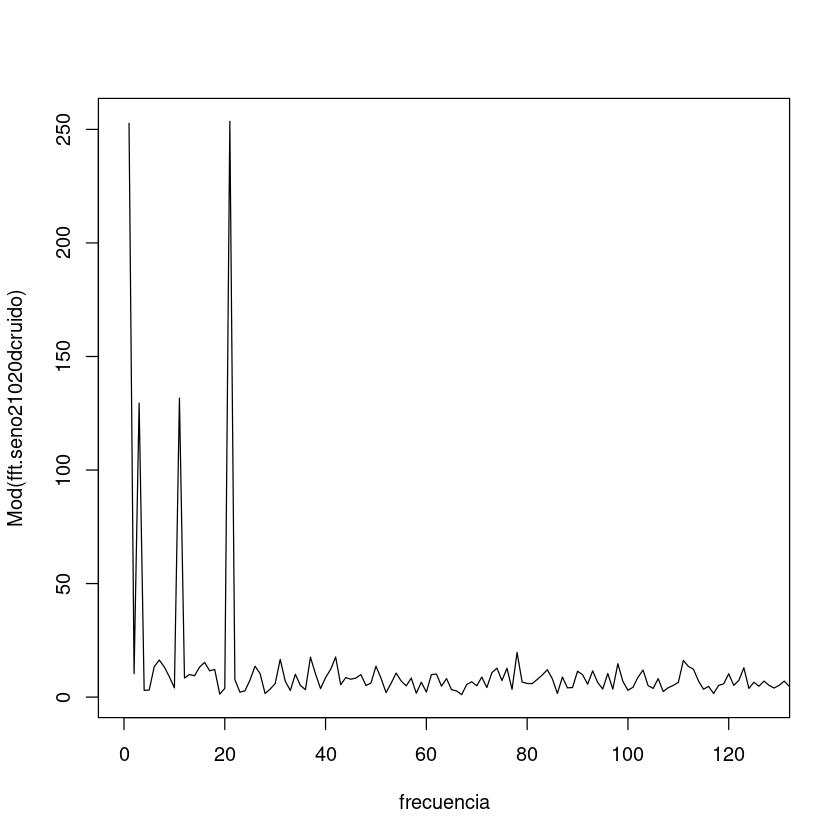

In [17]:
seno21020dcruido = seno2 + seno10 + seno20 + niveldc + nivelruido
fft.seno21020dcruido = fft(seno21020dcruido)

plot(tiempo, seno21020dcruido,type='l')
plot(Mod(fft.seno21020dcruido),type='l', xlab='frecuencia')

plot(Mod(fft.seno21020dcruido),type='l', xlab='frecuencia', xlim=c(0,127))


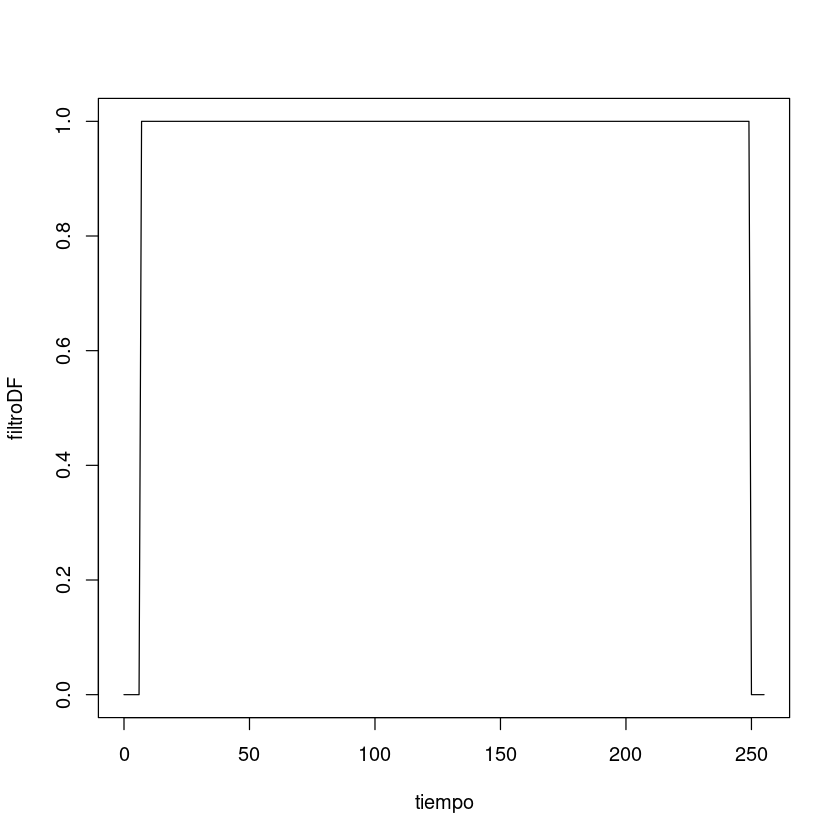

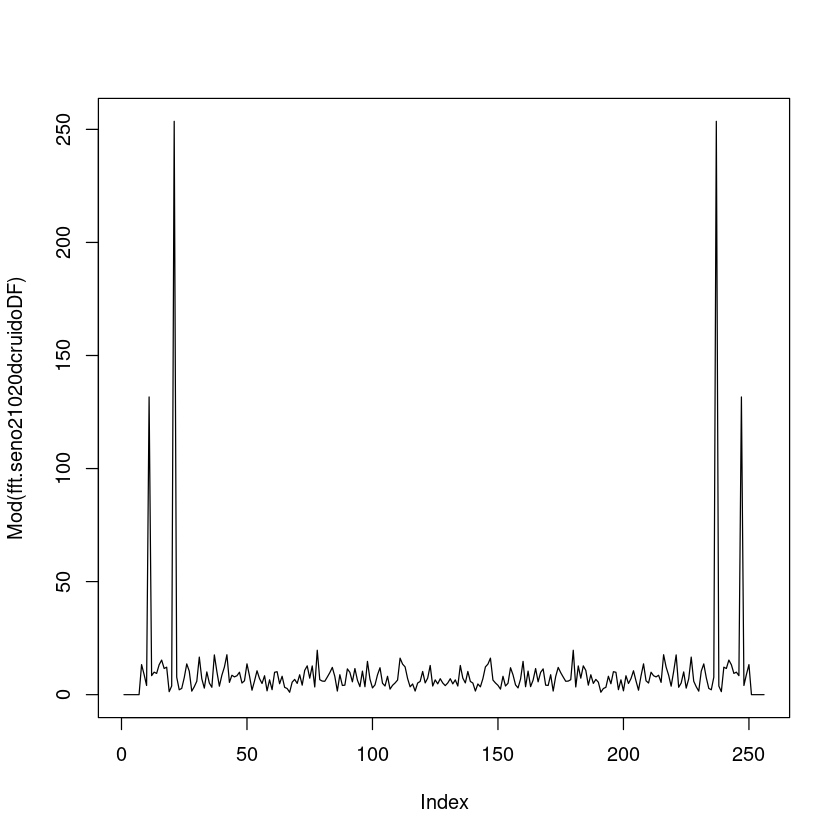

In [21]:
filtroDF = rep(1,N)
banda.filtro = 7
filtroDF[1:banda.filtro] = 0
filtroDF[(N-banda.filtro+2):N] = 0
fft.seno21020dcruidoDF = filtroDF*fft.seno21020dcruido

plot(tiempo, filtroDF ,type='l')
plot(Mod(fft.seno21020dcruidoDF), type='l')

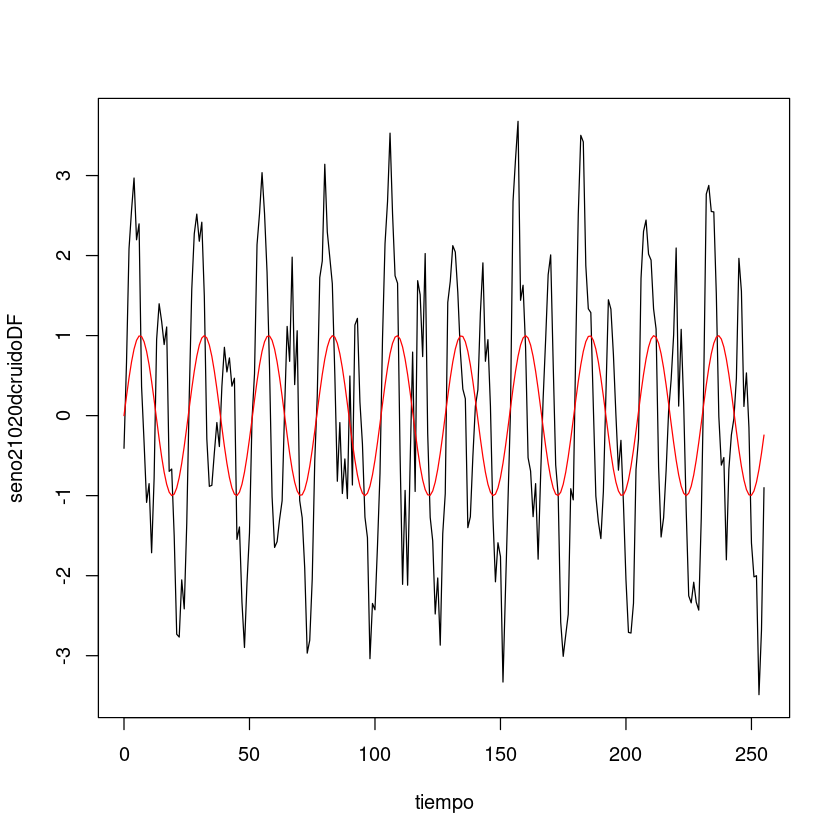

In [24]:
seno21020dcruidoDF = Re(fft(fft.seno21020dcruidoDF, inverse=TRUE)/N)
plot(tiempo, seno21020dcruidoDF, type='l')
lines(tiempo, seno10, col='red')

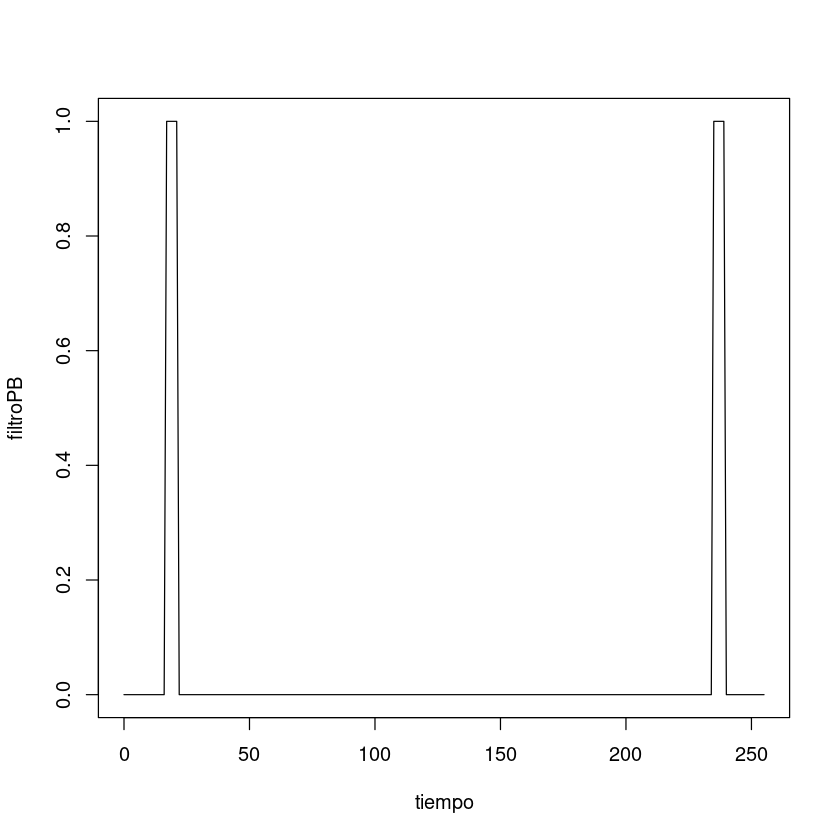

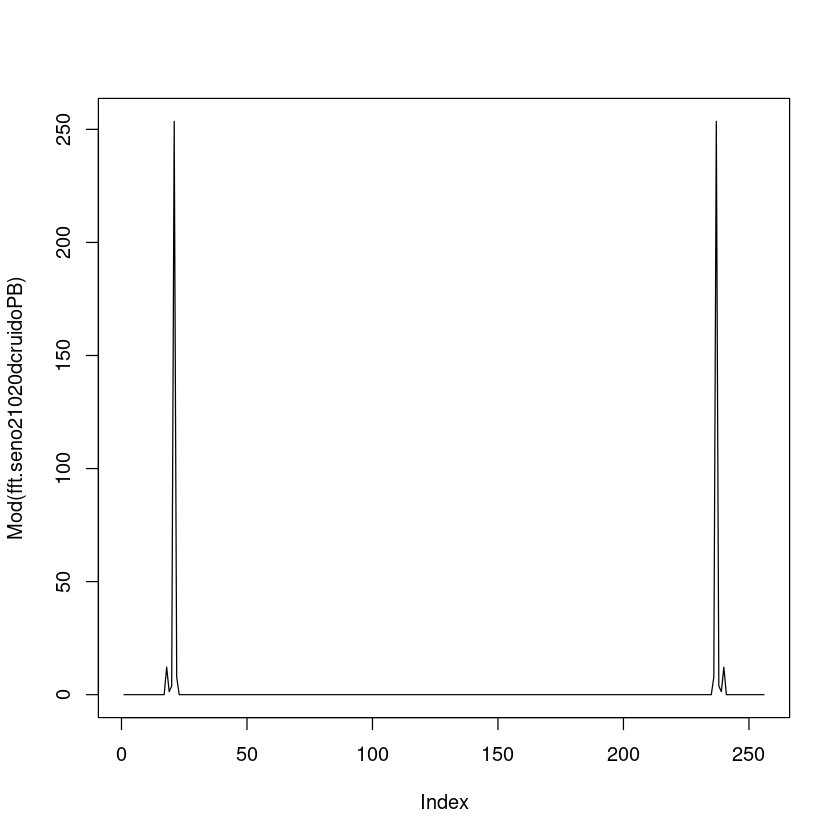

In [28]:
filtroPB = rep(0,N)
banda.filtro1 = 18
banda.filtro2 = 22

filtroPB[banda.filtro1:banda.filtro2] = 1
filtroPB[(N-banda.filtro2+2):(N-banda.filtro1+2)] = 1

fft.seno21020dcruidoPB = filtroPB*fft.seno21020dcruido

plot(tiempo, filtroPB, type='l')
plot(Mod(fft.seno21020dcruidoPB), type='l')


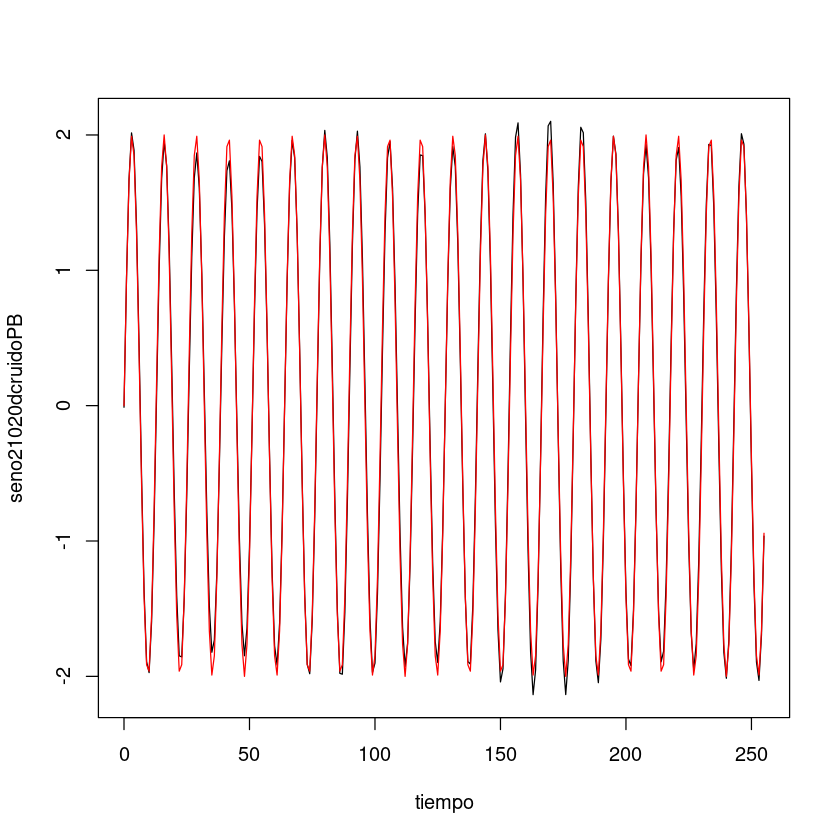

In [29]:
seno21020dcruidoPB = Re(fft(fft.seno21020dcruidoPB, inverse=TRUE)/N)
plot(tiempo, seno21020dcruidoPB, type='l')
lines(tiempo, seno20, col='red')

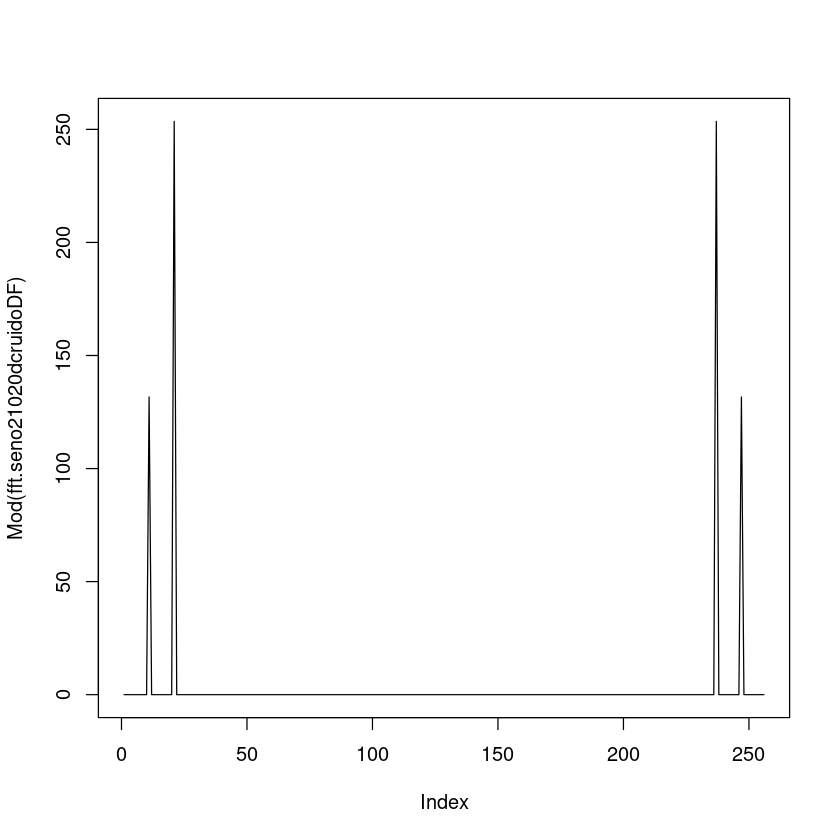

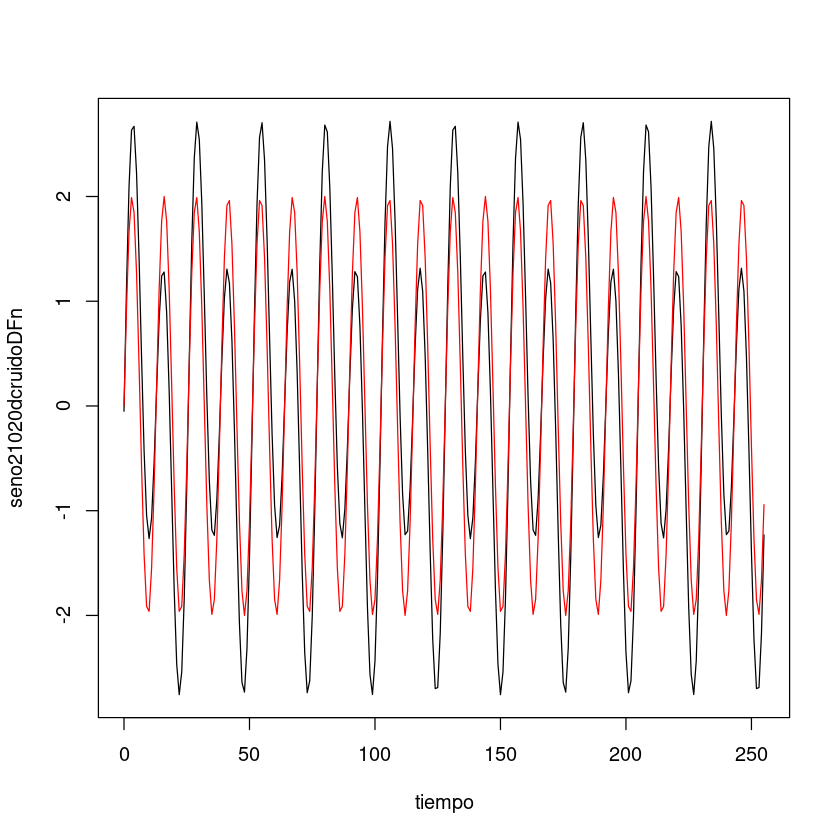

In [32]:
fft.seno21020dcruidoDF[Mod(fft.seno21020dcruidoDF)<50] = 0
plot(Mod(fft.seno21020dcruidoDF), type='l')

seno21020dcruidoDFn = Re(fft(fft.seno21020dcruidoDF, inverse=TRUE)/N)
plot(tiempo, seno21020dcruidoDFn, type='l')
lines(tiempo, seno20, col='red')